In [2]:
import numpy as np
import glob
import lgdo.lh5 as lh5
# import os, json
# import copy
# from pathlib import Path
# import shutil
import glob
import matplotlib.pyplot as plt
# from matplotlib.backends.backend_pdf import PdfPages
# from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
# import pandas as pd
# from tqdm.notebook import tqdm
import awkward as ak
import polars as pl
import awkward as ak

from bosonic_dm.cuts import compute_group_exposure
# from bosonic_dm.resolution import weighted_resolution_from_nested_dict as wres_full
# from bosonic_dm.resolution import weighted_resolution_per_detector as wres_det
# from bosonic_dm.resolution import weighted_value_per_det_type as wval_dtype
# from bosonic_dm.resolution import weighted_resolution_per_detector_type as wres_dtype
# from bosonic_dm.resolution import get_eres_per_detector
# import bosonic_dm.resolution as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}
_DET_TYPE_COLOR = {
    "BEGe": "tab:blue",
    "COAX": "tab:orange",
    "ICPC": "tab:green",
    "PPC": "tab:red",
    "ICPC_group1": "tab:purple",
    "ICPC_group2": "tab:brown",
}

simulated_energies = list(range(200, 1100, 100))

outdir_name = "./v1/parquet/"
dictionaries_dir = "./v1/dictionaries"

eres_dict = Props.read_from(f"{dictionaries_dir}/eres_dict.yaml")
rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd91dc1f880>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd91dc1f380>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd91dc2d850>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd91dc2d760>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd91dc4b330>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd91dc4ad40>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

In [3]:
pet_file = config['tier_pet']+'/phy/*.lh5'

pet_files = glob.glob(pet_file)

In [4]:
data = lh5.read_as(
    "evt", 
    pet_files[:2], 
    field_mask=["coincident", "geds", "trigger"],
    library="ak",
)

## Custom function

In [4]:
from bosonic_dm.cuts import prepare_pet_dataset, filter_dataset, apply_quality_cuts, compute_group_exposure
from bosonic_dm.plotting.spectra import plot_detector_spectra


In [4]:
pet_file = config['tier_pet']+'/phy/*.lh5'
pet_files = glob.glob(pet_file)

In [5]:
ICPC = [name for name in chmap.group('type')['icpc'].map('name')]
BEGe = [name for name in chmap.group('type')['bege'].map('name')]
COAX = [name for name in chmap.group('type')['coax'].map('name')]
PPC  = [name for name in chmap.group('type')['ppc'].map('name')]
def combine_dicts(dict_list, keys_list):
    if len(dict_list) != len(keys_list):
        raise ValueError("dict_list and keys_list must be the same length")
    
    return dict(zip(keys_list, dict_list))

### group division

In [6]:
ICPC_group1 = [
    'V05612B',
    'V09724A',
    'V05267A',
    'V05612A',
    'V08682B',
    'V05268B',
    'V08682A',
    'V09372A',
    'V09374A',
    'V04545A'
]

ICPC_group1_dict = {det:'all' for det in ICPC_group1}

ICPC_group1_dict['V08682B'] = {
    'p06': 'all',
    'p07': 'all',
    'p08': 'all',
    'p09': 'all',
}

ICPC_group1_dict['V01389A'] = {
    'p09': 'all',
}

ICPC_group1_dict

{'V05612B': 'all',
 'V09724A': 'all',
 'V05267A': 'all',
 'V05612A': 'all',
 'V08682B': {'p06': 'all', 'p07': 'all', 'p08': 'all', 'p09': 'all'},
 'V05268B': 'all',
 'V08682A': 'all',
 'V09372A': 'all',
 'V09374A': 'all',
 'V04545A': 'all',
 'V01389A': {'p09': 'all'}}

In [7]:
ICPC_group2_dict = {det:'all' for det in ICPC if det not in ICPC_group1}

ICPC_group2_dict['V01389A'] = 'all'
ICPC_group2_dict['V08682B'] = 'all'


for det in ICPC_group1_dict:

    if det in ICPC_group2_dict:
        ICPC_group2_dict[det] = {}

        for p in ICPC_group1_dict[det]:
            ICPC_group2_dict[det][f'~{p}'] = ICPC_group1_dict[det][p]

ICPC_group2_dict

{'V02160A': 'all',
 'V02160B': 'all',
 'V05261B': 'all',
 'V05266A': 'all',
 'V05266B': 'all',
 'V07647A': 'all',
 'V07647B': 'all',
 'V00074A': 'all',
 'V04549A': 'all',
 'V07298B': 'all',
 'V01386A': 'all',
 'V01403A': 'all',
 'V01404A': 'all',
 'V01406A': 'all',
 'V01415A': 'all',
 'V02162B': 'all',
 'V02166B': 'all',
 'V04199A': 'all',
 'V05267B': 'all',
 'V07646A': 'all',
 'V07302B': 'all',
 'V00048B': 'all',
 'V00050A': 'all',
 'V00050B': 'all',
 'V01387A': 'all',
 'V05261A': 'all',
 'V05268A': 'all',
 'V07302A': 'all',
 'V00048A': 'all',
 'V01240A': 'all',
 'V01389A': {'~p09': 'all'},
 'V08682B': {'~p06': 'all', '~p07': 'all', '~p08': 'all', '~p09': 'all'}}

In [10]:
BEGe_group_dict = {det:'all' for det in BEGe}

PPC_group_dict = {det:'all' for det in PPC}

COAX_group_dict = {det:'all' for det in COAX}

ICPC_group_dict = {det:'all' for det in ICPC}

In [22]:
# save detector groupings dictionaries

Props.write_to(f'{dictionaries_dir}/detector-grouping/ICPC_group1_dict.yaml', ICPC_group1_dict)
Props.write_to(f'{dictionaries_dir}/detector-grouping/ICPC_group2_dict.yaml', ICPC_group2_dict)
Props.write_to(f'{dictionaries_dir}/detector-grouping/BEGe_group_dict.yaml', BEGe_group_dict)
Props.write_to(f'{dictionaries_dir}/detector-grouping/PPC_group_dict.yaml', PPC_group_dict)
Props.write_to(f'{dictionaries_dir}/detector-grouping/COAX_group_dict.yaml', COAX_group_dict)

dict_list = [ICPC_group1_dict, ICPC_group2_dict, BEGe_group_dict, PPC_group_dict, COAX_group_dict]
key_dict_list = ['ICPC group1', 'ICPC group2', 'BEGe', 'PPC', 'COAX']
groups_dict = combine_dicts(dict_list, key_dict_list)

Props.write_to(f'{dictionaries_dir}/detector-grouping/groups_dict.yaml', groups_dict)

### Retrieve data

In [20]:
# read detector grouping dictionaries

ICPC_group1_dict = Props.read_from(f'{dictionaries_dir}/detector-grouping/ICPC_group1_dict.yaml')
ICPC_group2_dict = Props.read_from(f'{dictionaries_dir}/detector-grouping/ICPC_group2_dict.yaml')
BEGe_group_dict  = Props.read_from(f'{dictionaries_dir}/detector-grouping/BEGe_group_dict.yaml')
PPC_group_dict   = Props.read_from(f'{dictionaries_dir}/detector-grouping/PPC_group_dict.yaml')
COAX_group_dict  = Props.read_from(f'{dictionaries_dir}/detector-grouping/COAX_group_dict.yaml')

groups_dict      = Props.read_from(f'{dictionaries_dir}/detector-grouping/groups_dict.yaml')

In [6]:
def apply_multiplicity1(evt: ak.Array) -> ak.Array:
    mask = (
        (evt.geds.multiplicity == 1)
        & (ak.all(evt.geds.quality.is_good_channel, axis=-1))
        & (~evt.coincident.puls)
        & (~evt.trigger.is_forced)
        & (~evt.coincident.muon_offline)
        & (evt.coincident.geds)
        & (~evt.geds.quality.is_not_bb_like.is_delayed_discharge)
    )
    return evt[mask]


In [7]:
df_qc = prepare_pet_dataset(
    pet_files,
    chmap=chmap,
    field_mask=["coincident", "geds", "trigger"],
)

df_qc = df_qc.filter(~pl.col("coincident_spms"))

In [8]:
df_noqc = prepare_pet_dataset(
    pet_files,
    chmap=chmap,
    field_mask=["coincident", "geds", "trigger"],
    cut_func = apply_multiplicity1
)

df_noqc = df_noqc.filter(~pl.col("coincident_spms"))

In [119]:
groups = {
    "ICPC_group1": ICPC_group1_dict,
    "ICPC_group2": ICPC_group2_dict,
    "BEGe": BEGe_group_dict,
    "COAX": COAX_group_dict,
    "PPC": PPC_group_dict,
    "ICPC": ICPC_group_dict,
}
# Construct the energy dictionary
energy_dict = {
    group_name: {
        "QC": filter_dataset(df_all, group_dict)["energy"].to_numpy(),
        "no_QC": filter_dataset(df_noQC, group_dict)["energy"].to_numpy(),
        "expo": compute_group_exposure(eres_dict, group_dict),
    }
    for group_name, group_dict in groups.items()
}


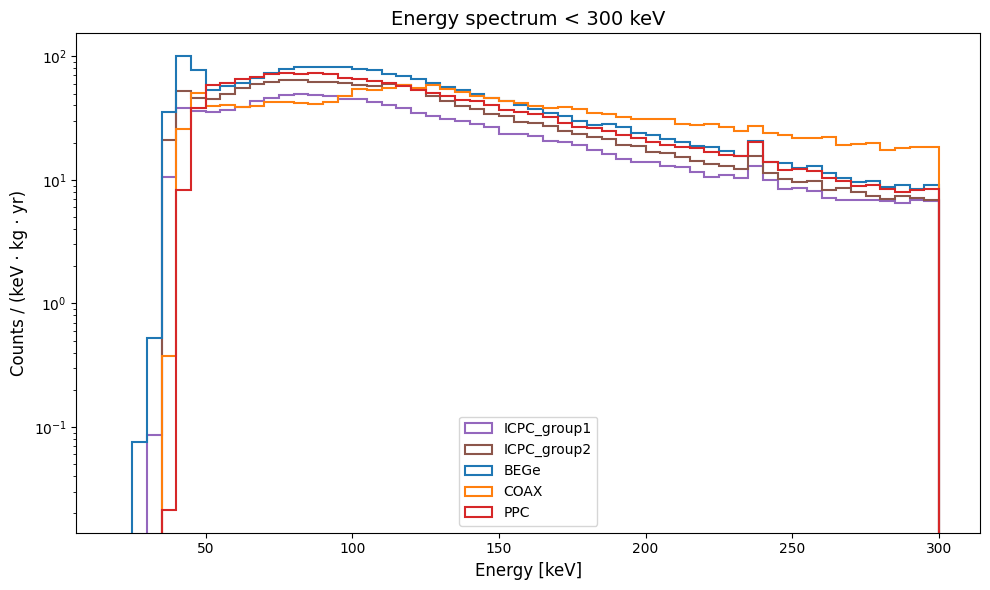

In [121]:
emin = 20
emax = 300

bins = int((emax-emin)/5)
bin_width = (emax - emin) / bins

plt.figure(figsize=(10, 6))

for group in groups:
    if group == "ICPC": continue
    tmp = energy_dict[group]
    plt.hist(tmp["QC"], bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR[group],
             weights=np.ones_like(tmp["QC"]) / (tmp["expo"]*bin_width), label=group)

# plt.hist(energia2, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['ICPC'], ls = '--',
#          weights=np.ones_like(energia2) / expo_group2, label="ICPC group2")

# plt.hist(energia_BEGe, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['BEGe'],
#          weights=np.ones_like(energia_BEGe) / expo_BEGe, label="BEGe")

# plt.hist(energia_PPC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['PPC'],
#          weights=np.ones_like(energia_PPC) / expo_PPC, label="PPC")
# plt.hist(energia_COAX, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['COAX'],
#          weights=np.ones_like(energia_COAX) / expo_COAX, label="COAX")

# plt.axvline(1024, ls='--')

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
# plt.savefig(f"./plots/bkg-stectra_{emax}.png", dpi=300)

plt.show()

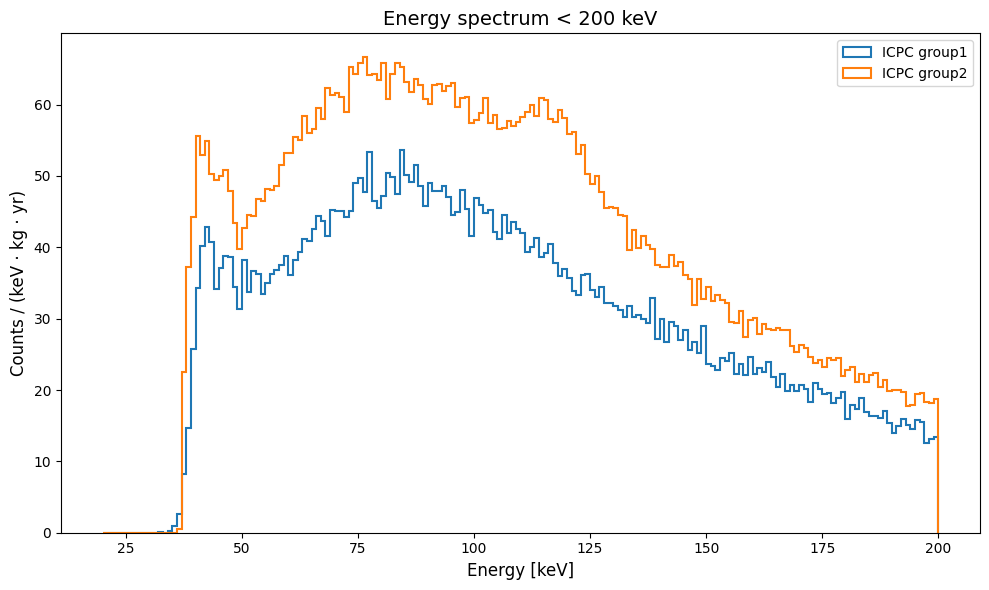

In [90]:
emin = 20
emax = 200

bins = emax-emin

plt.figure(figsize=(10, 6))


plt.hist(energia, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = 'tab:blue',
         weights=np.ones_like(energia) / expo_group1, label="ICPC group1")

# plt.hist(energia_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = 'tab:blue', ls = '--',
#          weights=np.ones_like(energia_noQC) / expo_group1_noQC, label="ICPC group1")

plt.hist(energia2, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = 'tab:orange',
         weights=np.ones_like(energia2) / expo_group2, label="ICPC group2")

# plt.hist(energia2_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = 'tab:orange', ls = '--',
#          weights=np.ones_like(energia2_noQC) / expo_group2_noQC, label="ICPC group2")


plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
# plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
# plt.savefig(f"./plots/bkg-stectra_{emax}.png", dpi=300)

plt.show()


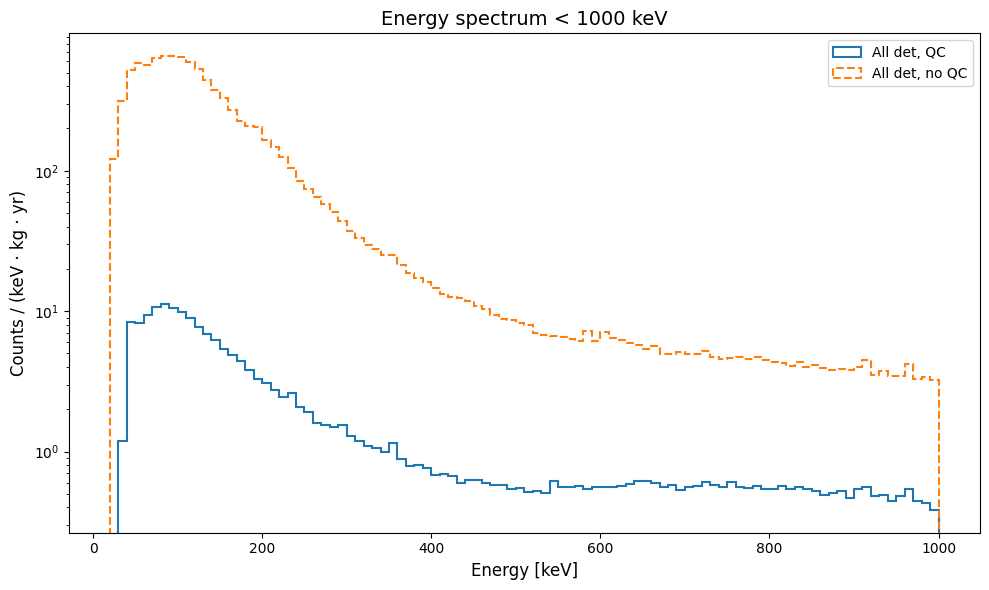

In [61]:
emin = 20
emax = 1000

full_energy = df_finale["energy"].to_numpy()
full_energy_noQC = df_noQC["energy"].to_numpy()


bins = int((emax-emin)/10)
bin_width = (emax - emin) / bins



plt.figure(figsize=(10, 6))


plt.hist(full_energy, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5,
         weights=np.ones_like(full_energy) / (tot_expo*bin_width), label='All det, QC')

plt.hist(full_energy_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, ls = '--',
         weights=np.ones_like(full_energy_noQC) / (tot_expo*bin_width), label='All det, no QC')

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"./plots/bkg-spectra_20-1000keV_all-dets.png", dpi=300)

plt.show()


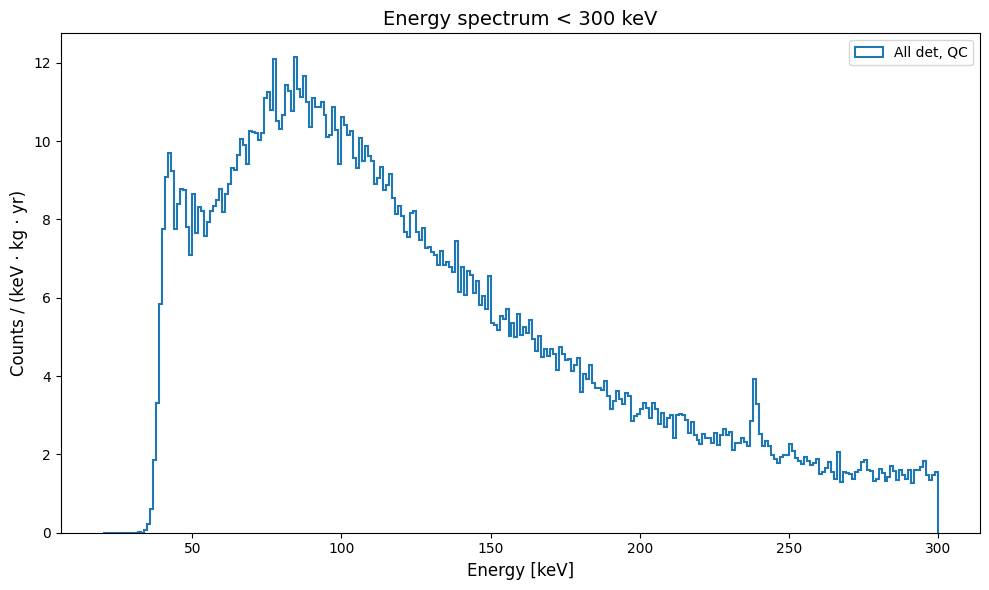

In [83]:
emin = 20
emax = 300

full_energy = df_finale["energy"].to_numpy()
full_energy_noQC = df_noQC["energy"].to_numpy()


bins = int((emax-emin))
bin_width = (emax - emin) / bins



plt.figure(figsize=(10, 6))


plt.hist(full_energy, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5,
         weights=np.ones_like(full_energy) / (tot_expo*bin_width), label='All det, QC')

# plt.hist(full_energy_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, ls = '--',
#          weights=np.ones_like(full_energy_noQC) / (tot_expo*bin_width), label='All det, no QC')

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
# plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"./plots/bkg-spectra_20-1000keV_all-dets_linear_onlyQC.png", dpi=300)

plt.show()


In [58]:
np.ones_like(full_energy_noQC) / tot_expo, np.ones_like(full_energy) / tot_expo

(array([0.0138296, 0.0138296, 0.0138296, ..., 0.0138296, 0.0138296,
        0.0138296], dtype=float32),
 array([0.0138296, 0.0138296, 0.0138296, ..., 0.0138296, 0.0138296,
        0.0138296], dtype=float32))

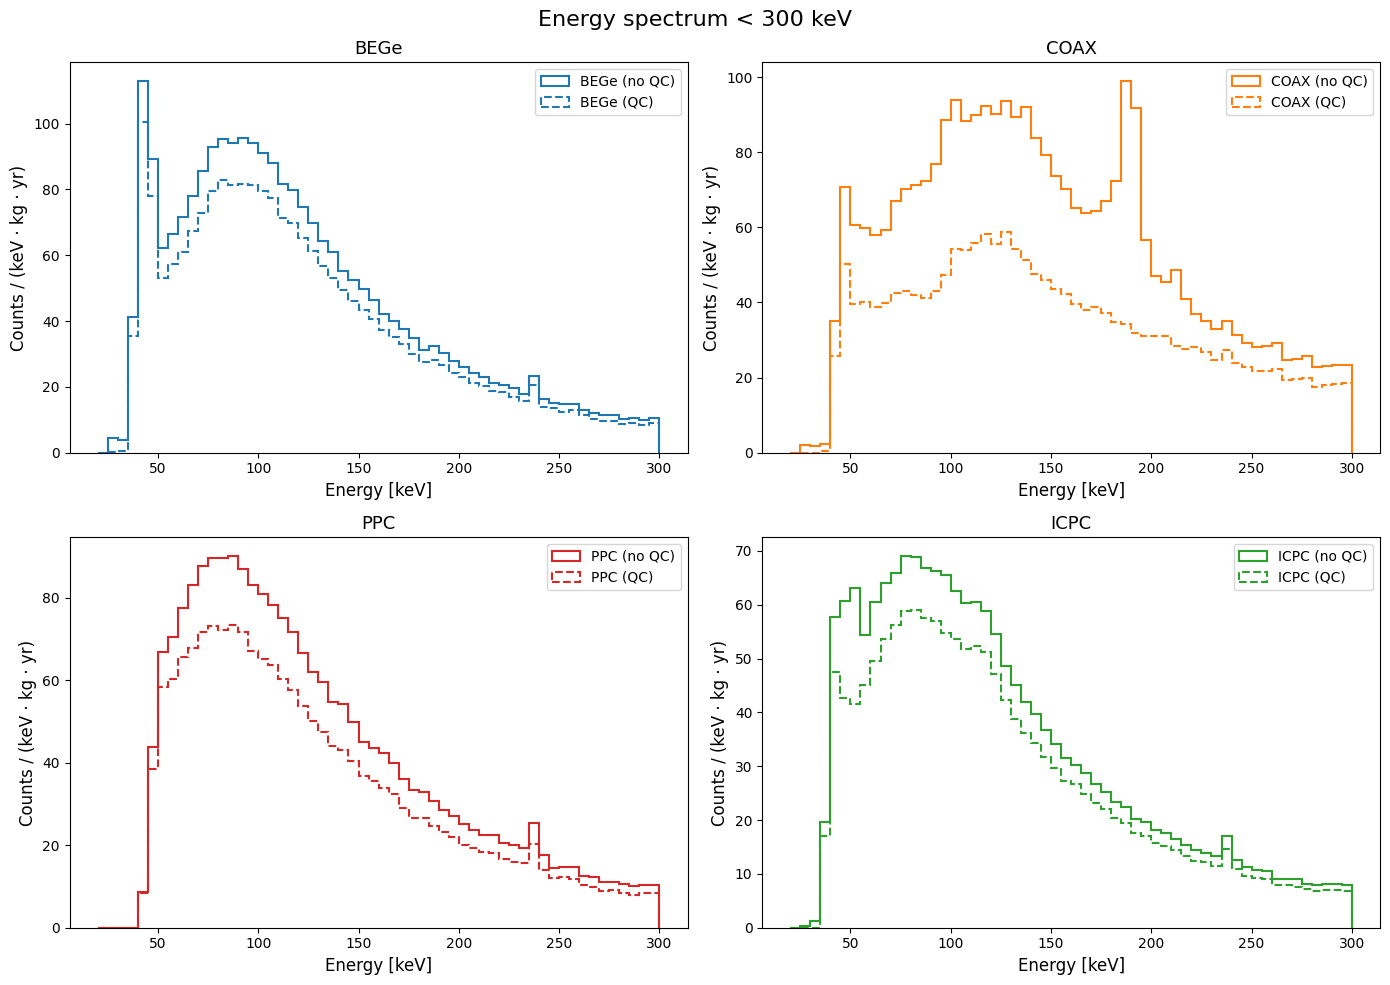

In [150]:
emin = 20
emax = 300

bins = int((emax-emin)/5)
bin_width = (emax - emin) / bins

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
        f"Energy spectrum < {emax} keV",
        fontsize=16,
    )
axes = axes.flat
i = 0
for det_type, tmp in energy_dict.items():

    if "group" in det_type: continue

    ax = axes[i]
    i += 1
        
    ax.hist(tmp['no_QC'], bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR[det_type],
             weights=np.ones_like(tmp['no_QC']) / (tmp['expo']*bin_width), label=f"{det_type} (no QC)")

    ax.hist(tmp['QC'], bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR[det_type], ls = '--',
         weights=np.ones_like(tmp['QC']) / (tmp['expo']*bin_width), label=f"{det_type} (QC)")

    
    ax.set_xlabel("Energy [keV]", fontsize=12)
    ax.set_ylabel("Counts / (keV · kg · yr)", fontsize=12)
    # ax.set_yscale("log")
    ax.set_title(det_type, fontsize=13)

    ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"./plots/bkg-spectra_{emin}-{emax}keV_detectors-type_linear.png", dpi=300)

plt.show()

In [ ]:
emin = 20
emax = 300

bins = int((emax-emin)/5)
bin_width = (emax - emin) / bins

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
        f"Energy spectrum < {emax} keV",
        fontsize=16,
    )
axes = axes.flat
i = 0
for det_type, tmp in energy_dict.items():

    if "group" in det_type: continue

    ax = axes[i]
    i += 1
        
    ax.hist(tmp['no_QC'], bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR[det_type],
             weights=np.ones_like(tmp['no_QC']) / (tmp['expo']*bin_width), label=f"{det_type} (no QC)")

    ax.hist(tmp['QC'], bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR[det_type], ls = '--',
         weights=np.ones_like(tmp['QC']) / (tmp['expo']*bin_width), label=f"{det_type} (QC)")

    
    ax.set_xlabel("Energy [keV]", fontsize=12)
    ax.set_ylabel("Counts / (keV · kg · yr)", fontsize=12)
    # ax.set_yscale("log")
    ax.set_title(det_type, fontsize=13)

    ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"./plots/bkg-spectra_{emin}-{emax}keV_detectors-type_linear.png", dpi=300)

plt.show()

In [10]:
yscale = 'log'

for yscale in ['log', 'linear']:
    pdf_filename =f"./plots/all-detector-bkg-spectra_{yscale}.pdf"
    energy_range = (25, 300)
    interval = (energy_range[1]-energy_range[0])
    bins = int(interval/5)
    bin_width = interval / bins
    
    
    plot_detector_spectra(
        df_qc,
        df_noqc,
        eres_dict,
        energy_range,
        bins,
        pdf_filename = pdf_filename,
        yscale = yscale,
    )

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f7c14fab920>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f7c14fa8590>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f7c14fa8400>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f7c14fa8950>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f7c14fc7420>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f7c14fc79c0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

  0%|          | 0/81 [00:00<?, ?it/s]

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f77fb351670>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f77fb350db0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f77fb351990>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f77fb351d50>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f77fb398ae0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f77fb3990d0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

  0%|          | 0/81 [00:00<?, ?it/s]

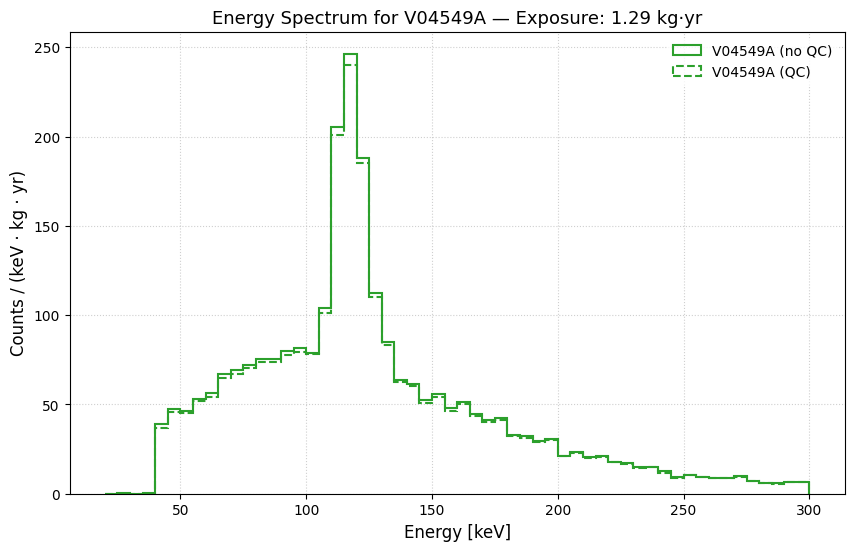

In [21]:
emin, emax = (20, 300)
interval = emax-emin
bins = int(interval/5)
bin_width = interval / bins
yscale = 'linear'

det_type = "ICPC"
color = _DET_TYPE_COLOR.get(det_type, "tab:gray")
det_name = 'V04549A'

# Filter data for this detector
df_det_qc = df_qc.filter(pl.col("detector_name") == det_name)
df_det_noqc = df_noqc.filter(pl.col("detector_name") == det_name)

energy_qc = df_det_qc["energy"].to_numpy()
energy_noqc = df_det_noqc["energy"].to_numpy()

# Compute exposure
expo = compute_group_exposure(eres_dict, {det_name: "all"})

fig, ax = plt.subplots(figsize=(10, 6))

weights_qc = np.ones_like(energy_qc) / (expo * bin_width)
weights_noqc = np.ones_like(energy_noqc) / (expo * bin_width)
y_label = "Counts / (keV · kg · yr)"
title_suffix = f"Exposure: {expo:.3g} kg·yr"

ax.hist(
    energy_noqc,
    bins=bins,
    range=(emin, emax),
    histtype="step",
    linewidth=1.5,
    color=color,
    linestyle="-",
    weights=weights_noqc,
    label=f"{det_name} (no QC)",
)

# Plot post-QC (QC) - dashed line
ax.hist(
    energy_qc,
    bins=bins,
    range=(emin, emax),
    histtype="step",
    linewidth=1.5,
    color=color,
    linestyle="--",
    weights=weights_qc,
    label=f"{det_name} (QC)",
)

ax.set_xlabel("Energy [keV]", fontsize=12)
ax.set_ylabel(y_label, fontsize=12)
ax.set_title(f"Energy Spectrum for {det_name} — {title_suffix}", fontsize=13)
ax.set_yscale(yscale)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=True, facecolor="white", edgecolor="none")

plt.show()

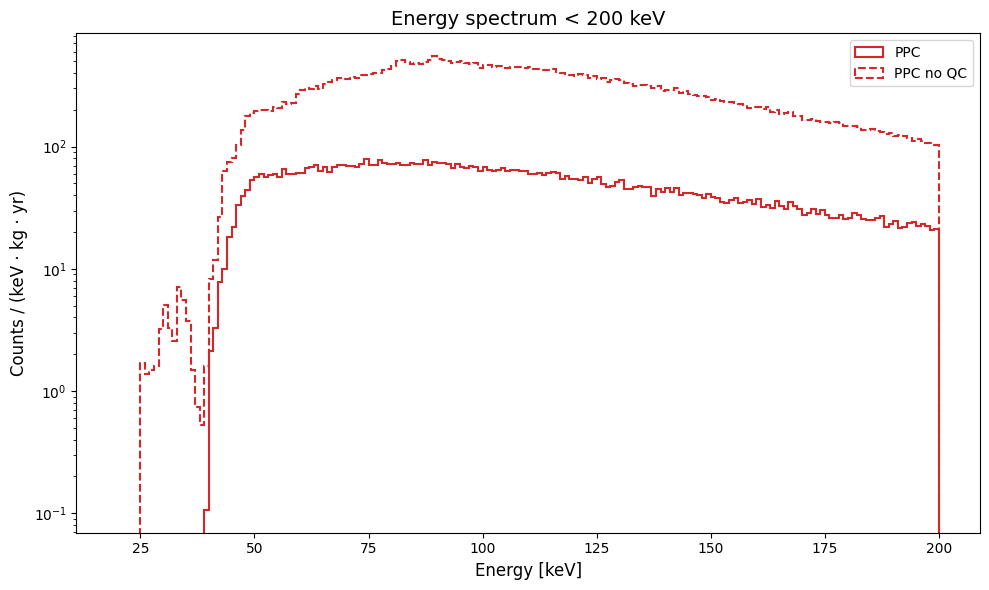

In [135]:
emin = 20
emax = 200

bins = emax-emin

plt.figure(figsize=(10, 6))


plt.hist(energia_PPC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['PPC'],
         weights=np.ones_like(energia_PPC) / expo_PPC, label="PPC")

plt.hist(energia_PPC_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['PPC'], ls = '--',
         weights=np.ones_like(energia_PPC_noQC) / expo_PPC_noQC, label="PPC no QC")

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
# plt.savefig(f"./plots/bkg-stectra_{emax}.png", dpi=300)

plt.show()

In [32]:
len(df_BEGe_noQC), len(np.unique(df_BEGe_noQC['hit_idx']))

(1221713, 3142)

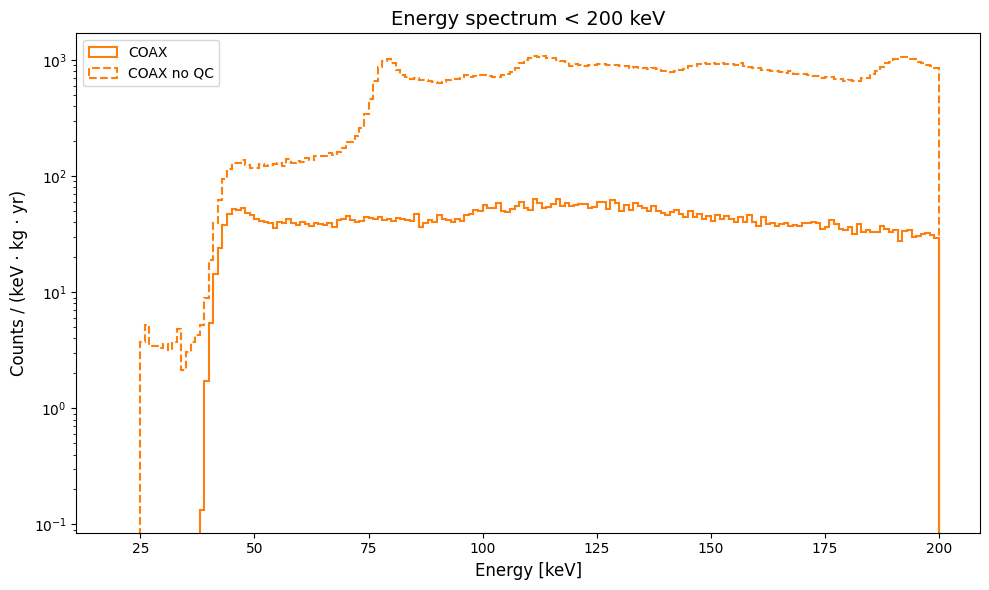

In [29]:
emin = 20
emax = 200

bins = emax-emin

plt.figure(figsize=(10, 6))

plt.hist(energia_COAX, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['COAX'],
         weights=np.ones_like(energia_COAX) / expo_COAX, label="COAX")

plt.hist(energia_COAX_noQC, bins=bins, range=(emin, emax), histtype="step", linewidth=1.5, color = _DET_TYPE_COLOR['COAX'], ls = '--',
         weights=np.ones_like(energia_COAX_noQC) / expo_COAX_noQC, label="COAX no QC")

plt.xlabel("Energy [keV]", fontsize=12)
plt.ylabel("Counts / (keV · kg · yr)", fontsize=12)
plt.title(f"Energy spectrum < {emax} keV", fontsize=14)
plt.yscale("log")
plt.legend(frameon=True)
plt.tight_layout()
# plt.savefig(f"./plots/bkg-stectra_{emax}.png", dpi=300)

plt.show()